# LAB 5

- Alunos:
    - Orlando Virginio Penha Junior
    - Bruno Osorio de Carvalho Almeida
    - Vinícius Ian Alves Lopes

## Imports

In [94]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

## Leitura dos Dados

In [4]:
df_attorneys = load_dataset("jamiequint/sf_criminal_court", "attorneys")["train"].to_pandas()
# df_calendar = load_dataset("jamiequint/sf_criminal_court", "calendar")["train"].to_pandas()
df_calendar_jud = load_dataset("jamiequint/sf_criminal_court", "calendar_with_judicial_assignments")["train"].to_pandas()
df_cases = load_dataset("jamiequint/sf_criminal_court", "cases")["train"].to_pandas()
df_da_arrests = load_dataset("jamiequint/sf_criminal_court", "da_arrests")["train"].to_pandas()
df_da_prosecuted = load_dataset("jamiequint/sf_criminal_court", "da_prosecuted")["train"].to_pandas()
# df_jud_assig_src = load_dataset("jamiequint/sf_criminal_court", "judicial_assignment_sources")["train"].to_pandas()
# df_jud_assig = load_dataset("jamiequint/sf_criminal_court", "judicial_assignments")["train"].to_pandas()
# df_jud_dept_assig = load_dataset("jamiequint/sf_criminal_court", "judicial_department_assignments")["train"].to_pandas()
# df_jud_officers = load_dataset("jamiequint/sf_criminal_court", "judicial_officers")["train"].to_pandas()
# df_register = load_dataset("jamiequint/sf_criminal_court", "register_of_actions")["train"].to_pandas()
# df_case_matches = load_dataset("jamiequint/sf_criminal_court", "sfsc_case_matches")["train"].to_pandas()
df_charge_disp = load_dataset("jamiequint/sf_criminal_court", "sfsc_charge_dispositions")["train"].to_pandas()

## Perguntas para direcionar a análise do Dataset
- 1- Qual é a taxa de casos em que a prisão ocorre por um crime grave (Felony), mas a promotoria decide formalizar a acusação apenas por um delito menor (Misdemeanor)?
- 2- Qual a duração média dos processos ? E processos com mais advogados tendem a ter mais movimentações ?
- 3- Os casos que nunca foram encerrados ou duraram mais de 1 ano são do mesmo juiz? Os crimes desses casos são semelhantes ou os advogados associados são os mesmos?
- 4- Quais os tipos de defensores mais atuantes na corte, publicos ou privados? Qual tipo consegue ser mais eficiente? (Resultado diferente de culpado)
- 5- Existe algum padrão de aumento ou queda no número de processos criminais dependendo do mês do ano?

## Pergunta 1

- 1- Qual é a taxa de casos em que a prisão ocorre por um crime grave (Felony), mas a promotoria decide formalizar a acusação apenas por um delito menor (Misdemeanor)?

A resposta dessa pergunta está relacionada com as tabelas de **df_da_arests** e **df_da_prosecuted**

### Análise Exploratória de Dados

In [ ]:
df_da_arrests.info()

In [ ]:
df_da_prosecuted.info()

In [ ]:
df_da_arrests.head()

In [ ]:
df_da_prosecuted.head()

In [ ]:
df_da_arrests.value_counts('booked_case_type').plot.barh()

In [ ]:
df_da_prosecuted.value_counts('filed_case_type').plot.barh()

Aqui notamos o valor de MTR, que significa Motion to Revoke ("Pedido de Revogação"), também notamos que há valores nulos nesse campo filed_case_type.

In [ ]:
df_da_prosecuted['filed_case_type'].unique()

In [ ]:
df_da_arrests['booked_case_type'].isna().sum()

#### Investigando os Dados nulos de df_da_prosecuted

Durante a análise exploratória, identificou-se que o campo filed_case_type do dataframe df_da_prosecuted apresentava valores ausentes (vazios) referentes à gravidade dos casos, devido a inconsistências no preenchimento original. Para mitigar a perda de dados, realizou-se a imputação de parte desses registros utilizando expressões regulares (Regex) para extrair as tipificações ('M' ou 'F') embutidas na coluna list_of_filed_charges. Os registros que ainda assim permaneceram nulos (NaN), por completa falta de informação em ambas as colunas, foram removidos do dataset para garantir a integridade da análise final.

In [ ]:
df_da_prosecuted[df_da_prosecuted['filed_case_type'] == '']

In [ ]:
letras_extraidas = df_da_prosecuted['list_of_filed_charges'].str.extract(r'/([MF])/')[0]

dicionario_traducao = {
    'M': 'Misdemeanor',
    'F': 'Felony'
}

valores_corrigidos = letras_extraidas.map(dicionario_traducao)
linhas_vazias = df_da_prosecuted['filed_case_type'] == ''

df_da_prosecuted.loc[linhas_vazias, 'filed_case_type'] = valores_corrigidos[linhas_vazias]

In [ ]:
df_da_prosecuted['filed_case_type'].isna().sum()

In [ ]:
df_da_prosecuted[df_da_prosecuted['filed_case_type'].isna()]

In [ ]:
df_da_prosecuted = df_da_prosecuted.dropna(subset=['filed_case_type'])

In [ ]:
df_da_prosecuted['filed_case_type'].isna().sum()

In [ ]:
df_da_prosecuted['filed_case_type'].value_counts()

### Merge das Tabelas para responder a pergunta

In [ ]:
df_pergunta1 = pd.merge(df_da_arrests,df_da_prosecuted,how='inner',on='incident_number')

In [ ]:
df_pergunta1.info()

In [ ]:
len(df_pergunta1[(df_pergunta1['booked_case_type'] == 'Felony') & (df_pergunta1['filed_case_type'] == 'Misdemeanor')])

O cálculo acima demonstra que houve 13.519 incidentes em que a autoridade policial registrou a prisão como um crime grave (Felony), mas a promotoria decidiu rebaixar a tipificação e formalizar a acusação apenas como um delito menor (Misdemeanor).

In [ ]:
len(df_pergunta1[df_pergunta1['booked_case_type'] == 'Felony'])

In [ ]:
casos_reducao = len(df_pergunta1[(df_pergunta1['booked_case_type'] == 'Felony') & (df_pergunta1['filed_case_type'] == 'Misdemeanor')])
total_felony = len(df_pergunta1[df_pergunta1['booked_case_type'] == 'Felony'])

print(f'Percentual: {casos_reducao/total_felony * 100:.2f}%')

A análise dos dados revela que, de um total de 98.207 prisões tipificadas preliminarmente como crimes graves, 13.519 sofreram desclassificação por parte da promotoria. Isso representa uma taxa de redução de 13,77%, evidenciando que uma parcela significativa dos casos perde força de acusação na transição entre a delegacia e o tribunal.

In [ ]:
df_pergunta1[(df_pergunta1['booked_case_type'] == 'Felony') & (df_pergunta1['filed_case_type'] == 'Misdemeanor')]

In [ ]:
df_casos_rebaixados = df_pergunta1[(df_pergunta1['booked_case_type'] == 'Felony') & (df_pergunta1['filed_case_type'] == 'Misdemeanor')]

df_casos_rebaixados['case_status'].value_counts()

### Resposta final para pergunta 1

A análise dos dados revelou que, de um total de 98.207 prisões registradas preliminarmente pela autoridade policial como crimes graves, 13.519 sofreram desclassificação por parte da promotoria, sendo formalmente protocoladas no tribunal apenas como delitos menores. Isso representa uma taxa de reclassificação de 13,77%.

Explorando os detalhes do dataset, foi possível compreender a o possível processo por trás desse "rebaixamento", que é impulsionada por três fatores principais:

1. A polícia frequentemente atua no calor do momento, enquadrando o suspeito na infração mais severa possível (ex: tráfico de drogas). No entanto, o órgão acusador (Promotoria) atua como um filtro. Ao analisar o caso e a viabilidade das provas, o promotor pode ajustar a denúncia, resultando em acusações mais brandas (ex: furto simples ou infração de trânsito).

2. Os dados demonstram um padrão processual em que as prisões originais recebem o status de rejeição (Discharged) por parte do promotor, seguido da abertura de uma denúncia inteiramente nova (New charges filed). Ao fazer uma pesquisa sobre o tema, foi visto que isso pode indicar uma ação do promotor de estar limpando o excesso da tipificação policial e protocolando o caso com a gravidade correta.

3. A análise do desfecho final (case_status) na última célula mostra que, dos 13.519 casos que sofreram rebaixamento de acusação, o destino mais frequente foi o Desvio Bem-Sucedido (Successful Diversion), com 3.464 ocorrências, indicando o redirecionamento do réu para programas de reabilitação. Logo em seguida, os acordos de culpa e condenações rápidas dominam o cenário (Conviction com 3.390 casos e Pled Guilty com 1.500 casos). Juntos, esses três desfechos representam mais de 60% das resoluções. Em contraste, apenas 141 casos resultaram em absolvição tradicional (Acquittal). Com mais pesquisas sobre o tema, foi encontrado uma explicação de que isso demonstra que a redução da gravidade do crime é amplamente utilizada pela promotoria como "moeda de troca" para garantir o encerramento do processo e evitar julgamentos onerosos.

Conclui-se que a taxa de 13,77% reflete o caminho natural de um caso nos Estados Unidos. O rigor inicial da polícia acaba sendo corrigido pelo promotor, que reduz a gravidade do crime após reavaliar as provas e negociar acordos de culpa.

## Pergunta 3

- 3- Os casos que nunca foram encerrados ou duraram mais de 1 ano são do mesmo juiz? Os crimes desses casos são semelhantes ou os advogados associados são os mesmos?

A resposta dessa pergunta está relacionada com as tabelas de **df_attorneys**, **df_calendar_jud** e **df_charge_disp**

### Pré-Processamento

In [121]:
df_attorneys.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72289 entries, 0 to 72288
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             72289 non-null  int64 
 1   case_number    72289 non-null  object
 2   name           72289 non-null  object
 3   attorney_type  72289 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.2+ MB


In [122]:
df_calendar_jud.info()

<class 'pandas.core.frame.DataFrame'>
Index: 318318 entries, 0 to 318992
Data columns (total 27 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   id                                318318 non-null  int64         
 1   case_number                       318318 non-null  object        
 2   court_date                        318318 non-null  object        
 3   hearing_type                      318318 non-null  object        
 4   location                          318318 non-null  object        
 5   dept                              318318 non-null  object        
 6   calendar_department               318318 non-null  object        
 7   calendar_date                     318318 non-null  datetime64[ns]
 8   assigned_judge                    318318 non-null  object        
 9   assigned_judges                   318318 non-null  object        
 10  assigned_judges_raw               318

In [123]:
df_charge_disp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44029 entries, 0 to 44028
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   sfsc_charge_id                  44029 non-null  int64         
 1   anon_case_id                    44029 non-null  object        
 2   case_number                     44029 non-null  object        
 3   charge_count                    44015 non-null  float64       
 4   filed_date                      44029 non-null  object        
 5   statute_number                  44029 non-null  object        
 6   normalized_statute              44029 non-null  object        
 7   normalized_charge_type_initial  44029 non-null  object        
 8   normalized_charge_modifier      44029 non-null  object        
 9   statute_description             44029 non-null  object        
 10  charge_type_initial             44029 non-null  object        
 11  ch

In [124]:
# Analisando o dataframe de calendário com juízes, percebemos muitos valores nulos na coluna 'assigned_judge_canonical_name'. Decidimos remover as linhas onde essa coluna é nula.
df_calendar_jud = df_calendar_jud[~df_calendar_jud['assigned_judge_canonical_name'].isna()]

In [125]:
df_calendar_jud['calendar_date'] = pd.to_datetime(
    df_calendar_jud['calendar_date']
)

# Para cada caso, queremos obter a data de início e os juízes envolvidos.
case_summary = (
    df_calendar_jud
    .groupby('case_number')
    .agg(
        start_date=('calendar_date', 'min'),
        judge=('assigned_judge_canonical_name',
               lambda x: ', '.join(sorted(set(x.dropna()))))
    )
    .reset_index()
)

In [126]:
# Agregando os advogados envolvidos em cada caso.
attorneys = (
    df_attorneys
    .groupby('case_number')
    .agg(
        attorneys=('name',
                   lambda x: ', '.join(sorted(set(x))))
    )
    .reset_index()
)

In [127]:
df_charge_disp['dispo_date'] = pd.to_datetime(
    df_charge_disp['dispo_date']
)


# Agregando os tipos de crime envolvidos em cada caso, data da decisão e informação de caso fechado.
charges = (
    df_charge_disp
    .groupby("case_number")
    .agg(
        last_dispo_date=('dispo_date', 'max'),
        crime_types=(
            "statute_description",
            lambda x: ", ".join(sorted(set(x.dropna())))
        ),
        closed_case=(
            'dispo_type',
            lambda x: x.notna().all()
        )
    )
    .reset_index()
)

In [128]:
# Unindo as informações de resumo do caso, advogados e tipos de crime em um único dataframe.
df_result = (
    case_summary
    .merge(attorneys, on="case_number", how="left")
    .merge(charges, on="case_number", how="left")
)

In [129]:
# Verificando quantos casos possuem dados nulos.
df_result.isna().sum()

case_number            0
start_date             0
judge                  0
attorneys           1502
last_dispo_date    16228
crime_types        10408
closed_case        10408
dtype: int64

In [133]:
df_result['case_duration'] = (
    df_result['last_dispo_date'] - df_result['start_date']
).dt.days

# Removendo casos que não possuem informações de advogados ou tipos de crime, as demais colunas podem estar relacionadas aos casos em aberto.
df_result = df_result.dropna(subset=['attorneys', 'crime_types'])

# Mantendo os casos com mais de um ano de duração ou caso fechado.
df_result = df_result[(df_result['case_duration'] > 365) | (df_result['closed_case'] == True)]

In [150]:
df_result

,case_number,start_date,judge,attorneys,last_dispo_date,crime_types,closed_case,case_duration
599,CRI22006124,2022-07-25,"Brian L. Ferrall, Gail Dekreon, Vedica Puri, V...","MIKE SILVEIRA, San Francisco District Attorney...",2024-04-08,"DRIVING UNDER THE INFLUENCE OF ALCOHOL, DRIVIN...",True,623.0
614,CRI22006251,2022-07-01,"A. Marisa Chun, Charles Crompton, Christopher ...","San Francisco District Attorney's Office, San ...",2022-10-21,BATTERY UPON AN OFFICER AND EMERGENCY PERSONNE...,True,112.0
616,CRI22006284,2022-07-01,"Charles Crompton, Christine Van Aken, Loretta ...","San Francisco District Attorney's Office, San ...",2022-07-18,"KILLING, MAIMING OR ABUSING ANIMALS",True,17.0
619,CRI22006325,2022-07-05,"A. Marisa Chun, Loretta M. Giorgi","Brittney Delgado, NEIL HALLINAN, San Francisco...",2023-06-28,"SEXUAL BATTERY BY RESTRAINT, SEXUAL PENETRATIO...",True,358.0
620,CRI22006326,2022-07-05,"Carolyn Gold, Gail Dekreon, Michael Rhoads, Ve...","San Francisco District Attorney's Office, San ...",2024-08-05,"DOMESTIC VIOLENCE, FALSE IMPRISONMENT",True,762.0
...,...,...,...,...,...,...,...,...
23132,CRI26402169,2026-02-13,Brian J. Stretch,"James Robbins, Liliana Garcia",2026-02-13,LOITERING TO COMMIT CONTROLLED SUBSTANCE OFFEN...,True,0.0
23154,CRI26403536,2026-03-02,"Brian J. Stretch, Visiting Judge","Anjuli Webb, Michael Foley",2026-04-02,UNAUTHORIZED LODGING,True,31.0
23155,CRI26403538,2026-03-02,"Brian J. Stretch, Maria E. Evangelista","GINA KUNG, James Filling",NaT,"POSSESSION OF GRAFFITI INSTRUMENTS, RESISTING,...",True,NaN
23186,CRI26404807,2026-03-23,"Brian J. Stretch, Maria E. Evangelista",GINA KUNG,NaT,CARRYING A SWITCHBLADE KNIFE,True,NaN


### Análise Exploratória dos Dados

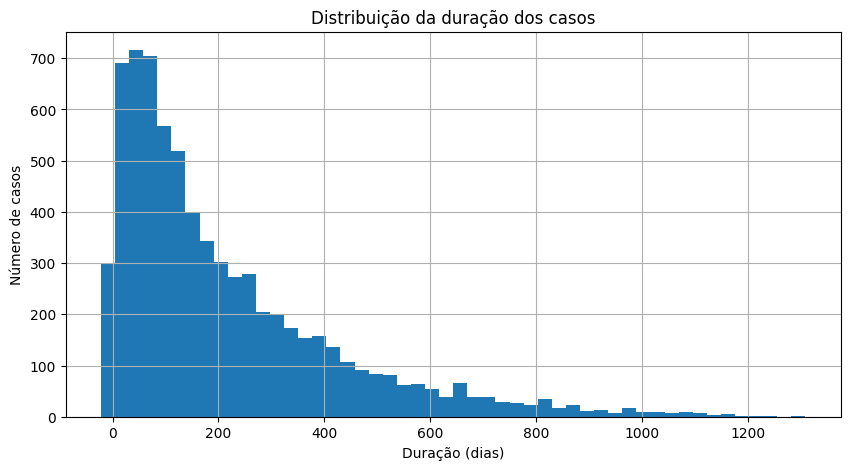

In [ ]:
plt.figure(figsize=(10,5))
df_result['case_duration'].dropna().hist(bins=50)
plt.xlabel('Duração (dias)')
plt.ylabel('Número de casos')
plt.title('Distribuição da duração dos casos')
plt.show()

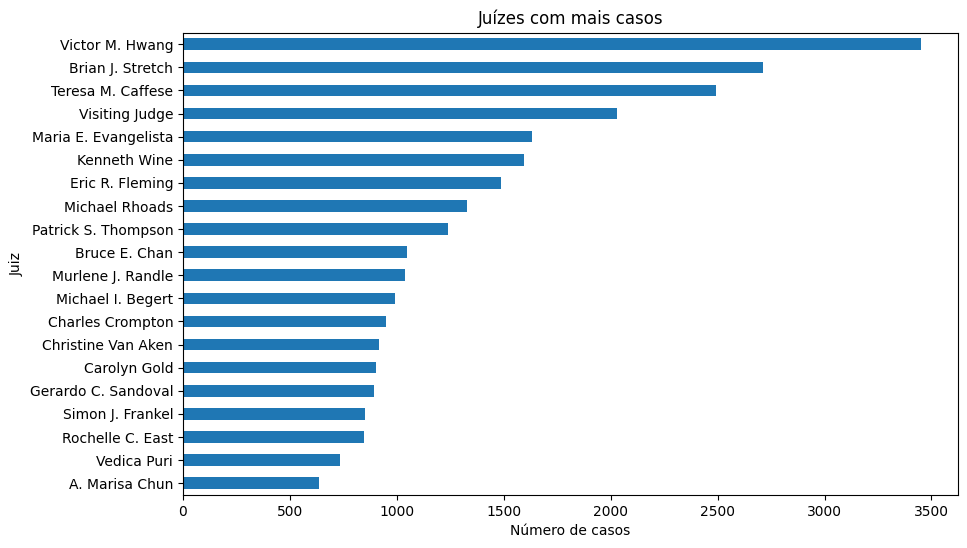

In [159]:
judge_df = (
    df_result[['case_number', 'judge']]
    .copy()
)

judge_df['judge'] = judge_df['judge'].str.split(',')

judge_df = judge_df.explode('judge')

judge_df['judge'] = judge_df['judge'].str.strip()

top_judges = judge_df['judge'].value_counts().head(20)

plt.figure(figsize=(10,6))
top_judges.sort_values().plot(kind='barh')
plt.title('Juízes com mais casos')
plt.xlabel('Número de casos')
plt.ylabel('Juiz')
plt.show()

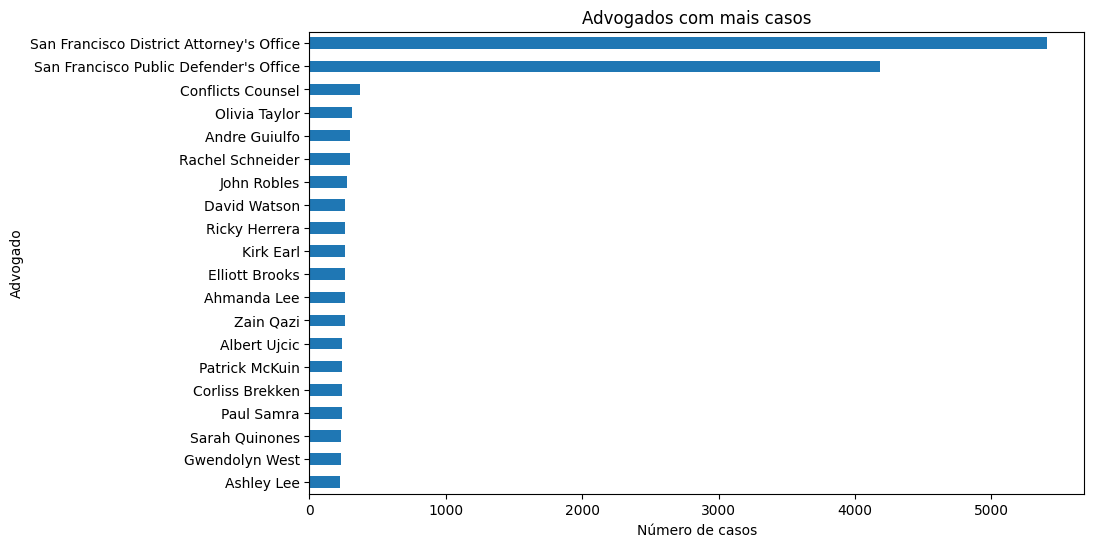

In [166]:
attorney_df = (
    df_result[['case_number', 'attorneys']]
    .copy()
)

attorney_df['attorneys'] = attorney_df['attorneys'].str.split(',')
attorney_df = attorney_df.explode('attorneys')
attorney_df['attorneys'] = attorney_df['attorneys'].str.strip()

top_attorneys = attorney_df['attorneys'].value_counts().head(20)

plt.figure(figsize=(10,6))
top_attorneys.sort_values().plot(kind='barh')
plt.title('Advogados com mais casos')
plt.xlabel('Número de casos')
plt.ylabel('Advogado')
plt.show()

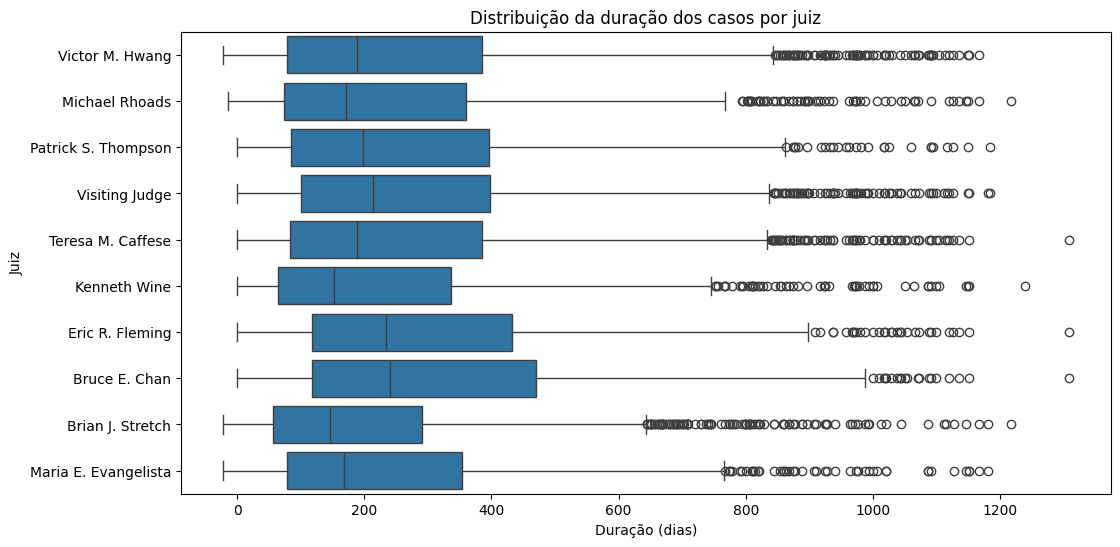

In [160]:
top_judges = (
    judge_df['judge']
    .value_counts()
    .head(10)
    .index
)

box_df = judge_df.merge(
    df_result[['case_number', 'case_duration']],
    on='case_number'
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=box_df[box_df['judge'].isin(top_judges)],
    x='case_duration',
    y='judge'
)

plt.title('Distribuição da duração dos casos por juiz')
plt.xlabel('Duração (dias)')
plt.ylabel('Juiz')
plt.show()

<Axes: ylabel='crime_types'>

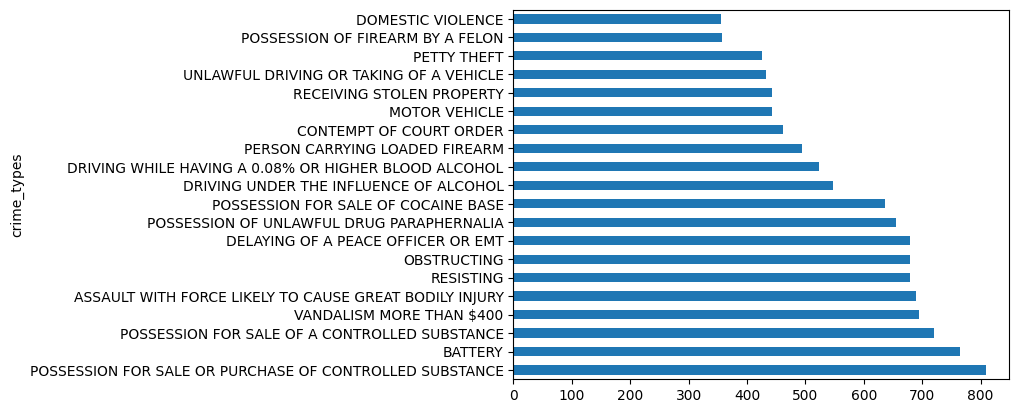

In [146]:
crime_df = (
    df_result[['case_number', 'crime_types']]
    .dropna()
)

crime_df['crime_types'] = crime_df['crime_types'].str.split(',')

crime_df = crime_df.explode('crime_types')

crime_df['crime_types'] = crime_df['crime_types'].str.strip()

crime_df['crime_types'].value_counts().head(20).plot.barh()

In [148]:
df_result.nlargest(
    20,
    'case_duration'
)[[
    'case_number',
    'judge',
    'case_duration',
    'crime_types',
    'attorneys'
]]

,case_number,judge,case_duration,crime_types,attorneys
837,CRI22009486,"A. Marisa Chun, Bruce E. Chan, Christopher C. ...",1308.0,"POSSESSION FOR SALE OF A CONTROLLED SUBSTANCE,...","Andre Guiulfo, Axell Hernandez, Dennis Chow, S..."
1096,CRI22012923,"Charles Crompton, Christine Van Aken, Kenneth ...",1240.0,"ASSAULT WITH A DEADLY WEAPON NOT A FIREARM, AS...","San Francisco District Attorney's Office, San ..."
1140,CRI22013363,"Brian J. Stretch, Carolyn Gold, Michael Rhoads",1217.0,"INFLICTING INJURY ON ELDER OR DEPENDENT ADULT,...","Ahmanda Lee, Austin Weis, Charlotte Miller, Je..."
1243,CRI22014687,"Christine Van Aken, Michael McNaughton, Murlen...",1185.0,"POSSESSION OF A CONTROLLED SUBSTANCE, RESISTIN...","San Francisco District Attorney's Office, San ..."
1839,CRI23001199,"Brian J. Stretch, Brian L. Ferrall, Maria E. E...",1181.0,"BATTERY, BATTERY UPON AN OFFICER AND EMERGENCY...","Michael Foley, Owen Nelson, San Francisco Dist..."
722,CRI22007858,"Brian J. Stretch, Gail Dekreon, Maria E. Evang...",1167.0,"FELON POSS/ETC STUN GUN, POSSESSION, USE OF TE...","Austin Weis, David Watson, San Francisco Distr..."
1841,CRI23001201,"A. Marisa Chun, Bruce E. Chan, Christine Van A...",1152.0,"RECEIVING STOLEN PROPERTY, MOTOR VEHICLE","Safa Lele, San Francisco District Attorney's O..."
1417,CRI22409564,"A. Marisa Chun, Kenneth Wine, Maria E. Evangel...",1151.0,ASSAULT UPON A PEACE OFFICER WITH A DEADLY WEA...,"Gwendolyn West, MICHAEL GAINES, San Francisco ..."
1147,CRI22013409,"Christine Van Aken, Murlene J. Randle, Patrick...",1150.0,"GRAND THEFT, POSSESSION OF CONTROLLED SUBSTANC...","Katharine Bryant, Ricky Herrera, San Francisco..."
889,CRI22010202,"Adrienne L. Rogers, Brian L. Ferrall, Carolyn ...",1149.0,"HAVING A CONCEALED FIREARM IN A VEHICLE, PERSO...","Aaron Johnson, Andre Guiulfo, CHERYL RICH, Ros..."


### Resposta da Pergunta 3

- A análise dos juízes mostrou que os casos longos ou sem encerramento não estão concentrados em um único juiz. Embora alguns juízes apareçam com maior frequência, especialmente Brian J. Stretch, Maria E. Evangelista e Victor M. Hwang, os boxplots de duração indicaram que casos extremamente longos estão distribuídos entre diferentes juízes. Isso sugere que a demora está mais relacionada à complexidade dos processos do que à atuação de um juiz específico.
- Os casos que permaneceram ativos por mais de um ano ou sem encerramento registrado apresentam uma concentração em alguns tipos de crime recorrentes, principalmente vandalismo, agressões, tráfico ou posse para venda de drogas, receptação de veículos roubados, furtos e infrações relacionadas à direção sob efeito de álcool ou drogas. Esse padrão sugere que os processos mais demorados compartilham características semelhantes e tendem a exigir maior acompanhamento judicial.
- Não foram encontradas evidências de forte concentração em advogados específicos. Embora alguns profissionais apareçam repetidamente nos casos analisados, as frequências são relativamente próximas entre si. Os nomes mais comuns pertencem principalmente ao San Francisco District Attorney's Office e ao San Francisco Public Defender's Office, o que era esperado devido ao papel institucional dessas organizações na maioria dos processos criminais. Portanto, a longa duração dos casos não parece estar associada a advogados específicos.

## Pergunta 5
- 5- Análise de Sazonalidade no Tribunal Criminal de São Francisco. Existe algum padrão de aumento ou queda no número de processos criminais dependendo do mês do ano?

In [ ]:
df_cases.head()

In [ ]:
df_cases['filed_date'] = pd.to_datetime(df_cases['filed_date'], errors='coerce')

linhas_antes = len(df_cases)
df_cases = df_cases.dropna(subset=['filed_date'])
linhas_depois = len(df_cases)
print(f"Linhas sem data removidas: {linhas_antes - linhas_depois}")

df_cases['mes_abertura'] = df_cases['filed_date'].dt.month
df_cases['ano_abertura'] = df_cases['filed_date'].dt.year

df_cases[['case_number', 'filed_date', 'mes_abertura', 'ano_abertura']].head()

In [ ]:
casos_por_mes_total = df_cases.groupby('mes_abertura')['case_number'].count()

casos_por_ano_mes = df_cases.groupby(['ano_abertura', 'mes_abertura'])['case_number'].count().reset_index()
casos_por_ano_mes.rename(columns={'case_number': 'total_casos'}, inplace=True)

anos_completos = casos_por_ano_mes['ano_abertura'].value_counts()
anos_validos = anos_completos[anos_completos == 12].index
casos_por_ano_mes = casos_por_ano_mes[casos_por_ano_mes['ano_abertura'].isin(anos_validos)]

print("Agregações concluídas.")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
meses_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

axes[0].bar(casos_por_mes_total.index, casos_por_mes_total.values, color='royalblue')
axes[0].set_title('Total de Casos Histórico por Mês', fontsize=14)
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Volume Total de Casos')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses_labels)

casos_por_ano_mes['data_plot'] = pd.to_datetime(
    casos_por_ano_mes['ano_abertura'].astype(str) + '-' + casos_por_ano_mes['mes_abertura'].astype(str) + '-01'
)
casos_por_ano_mes = casos_por_ano_mes.sort_values('data_plot')

axes[1].plot(casos_por_ano_mes['data_plot'], casos_por_ano_mes['total_casos'], marker='o', color='darkorange')
axes[1].set_title('Volume de Casos ao Longo do Tempo', fontsize=14)
axes[1].set_xlabel('Ano-Mês')
axes[1].set_ylabel('Casos por Mês')
axes[1].tick_params(axis='x', rotation=45)

dados_boxplot = [casos_por_ano_mes[casos_por_ano_mes['mes_abertura'] == i]['total_casos'].values for i in range(1, 13)]

axes[2].boxplot(dados_boxplot, labels=meses_labels, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[2].set_title('Distribuição Sazonal (Boxplot)', fontsize=14)
axes[2].set_xlabel('Mês')
axes[2].set_ylabel('Variação do Volume de Casos (Anos)')

plt.tight_layout()
plt.show()

- Os meses de Fevereiro e Novembro apresentam os menores volumes totais (Gráfico 1) e também as menores variâncias e medianas no Boxplot.
- Meses como Abril e Julho concentram o maior volume histórico, porém, o Boxplot indica que o comportamento não é estável todos os anos; os números foram puxados para cima por eventos atípicos recentes.
- O gráfico de linhas (Gráfico 2) mostra uma explosão estrutural. O volume sai de um patamar baixo e estável em 2022 e inflama violentamente a partir do final de 2023, mantendo extrema volatilidade ao longo de 2024 e 2025.